# Step 3 — Offline baselines (ZOH / Linear / PID)

Upsample sparse VLA joint targets to 100 Hz **without** an ESN, score against demo joints.

**Default episodes:** canonical **held-out** `160–199` (never used for ESN training).
Also run `train` if you want an in-sample reference table.

| Method | Meaning |
|--------|---------|
| `zoh` | Hold last VLA target (staircase) |
| `linear` | Straight-line blend between VLA knots |
| `pid` | Simple joint PID toward held VLA targets |

Live closed-loop → `step3_dual_thread_mujoco.ipynb`.


In [1]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    RESEARCH_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "src" / "step3_control_baselines.py").is_file():
    RESEARCH_DIR = NOTEBOOK_DIR
else:
    RESEARCH_DIR = NOTEBOOK_DIR / "research_summer_2026" / "research"
    if not RESEARCH_DIR.is_dir():
        RESEARCH_DIR = NOTEBOOK_DIR / "research"

RESEARCH_DIR = RESEARCH_DIR.resolve()
assert (RESEARCH_DIR / "src").is_dir(), f"src package not found under: {RESEARCH_DIR}"

os.chdir(RESEARCH_DIR)
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

print(f"Research root : {RESEARCH_DIR}")
print(f"Results go to : {RESEARCH_DIR / 'results' / 'step3_baselines'}")


Research root : /home/aihimekpen/research_summer_2026/research
Results go to : /home/aihimekpen/research_summer_2026/research/results/step3_baselines


In [2]:
# ── Configuration ───────────────────────────────────────────
EPISODES_SPEC = "heldout"   # heldout | train | all | 160-163 | 0-7
MAX_EPISODES = None          # e.g. 8 for a quick pass
METHODS = ["zoh", "linear", "pid"]

from src.wipe_dataset import parse_episode_spec, split_name_for_episodes
EPISODES = parse_episode_spec(EPISODES_SPEC)
if MAX_EPISODES is not None:
    EPISODES = EPISODES[:MAX_EPISODES]
SPLIT_TAG = split_name_for_episodes(EPISODES)
print(f"split={SPLIT_TAG} | n_episodes={len(EPISODES)} | methods={METHODS}")
print(f"episodes: {EPISODES[0]}…{EPISODES[-1]}")


split=heldout | n_episodes=40 | methods=['zoh', 'linear', 'pid']
episodes: 160…199


In [3]:
import json
from dataclasses import asdict

import pandas as pd
from IPython.display import display

from src.paths import results_path
from src.step3_control_baselines import (
    run_baselines_multi,
    summarize_baselines_by_method,
    write_comparison_table,
)

out_dir = results_path("step3_baselines")
eval_dir = results_path("step3_evaluation")
out_dir.mkdir(parents=True, exist_ok=True)
eval_dir.mkdir(parents=True, exist_ok=True)

results = run_baselines_multi(EPISODES, methods=METHODS)
for r in results:
    path = out_dir / f"baseline_{r.method}_ep{r.episode}.json"
    path.write_text(json.dumps(asdict(r), indent=2))

csv_path = write_comparison_table(results, out_dir)
write_comparison_table(results, eval_dir)
tagged = out_dir / f"baseline_comparison_{SPLIT_TAG}.csv"
tagged.write_text(csv_path.read_text())

summary = summarize_baselines_by_method(results)
display(pd.DataFrame(summary))
display(pd.DataFrame([asdict(r) for r in results]).head(12))
print(f"Per-episode CSV: {csv_path}")
print(f"Tagged copy:     {tagged}")
print(f"Summary JSON:    {out_dir / 'baseline_comparison_summary.json'}")


/raid/data/aihimekpen/venvs/research_summer_2026/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-05 16:52:40,912 [INFO] Wrote comparison table: /home/aihimekpen/research_summer_2026/research/results/step3_baselines/baseline_comparison.csv
2026-08-05 16:52:40,919 [INFO] Wrote comparison table: /home/aihimekpen/research_summer_2026/research/results/step3_evaluation/baseline_comparison.csv


,method,n_episodes,rmse_mean,rmse_std,jerk_mean,jerk_std
0,zoh,40.0,0.053898,0.009435,0.000166,0.000063
1,linear,40.0,0.015489,0.003930,0.000003,0.000001
2,pid,40.0,0.071357,0.011903,0.000005,0.000002


,method,episode,mse,rmse,jerk,jerk_rms,control_hz,vla_hz,n_joints
0,zoh,160,0.003383,0.058164,0.000213,35796.562473,100.0,2.0,29
1,linear,160,0.000359,0.018934,0.000004,482.594973,100.0,2.0,29
2,pid,160,0.006319,0.079491,0.000006,1146.577395,100.0,2.0,29
3,zoh,161,0.003110,0.055768,0.000177,32623.922565,100.0,2.0,29
4,linear,161,0.000164,0.012805,0.000004,444.403916,100.0,2.0,29
5,pid,161,0.005482,0.074042,0.000005,1044.956027,100.0,2.0,29
6,zoh,162,0.002695,0.051918,0.000149,29902.170273,100.0,2.0,29
7,linear,162,0.000171,0.013073,0.000003,385.836560,100.0,2.0,29
8,pid,162,0.004794,0.069240,0.000004,957.778043,100.0,2.0,29
9,zoh,163,0.002647,0.051446,0.000151,30123.093233,100.0,2.0,29


Per-episode CSV: /home/aihimekpen/research_summer_2026/research/results/step3_baselines/baseline_comparison.csv
Tagged copy:     /home/aihimekpen/research_summer_2026/research/results/step3_baselines/baseline_comparison_heldout.csv
Summary JSON:    /home/aihimekpen/research_summer_2026/research/results/step3_baselines/baseline_comparison_summary.json


,method,n_episodes,rmse_mean,rmse_std,jerk_mean,jerk_std
0,zoh,40.0,0.053898,0.009435,0.000166,0.000063
1,linear,40.0,0.015489,0.003930,0.000003,0.000001
2,pid,40.0,0.071357,0.011903,0.000005,0.000002


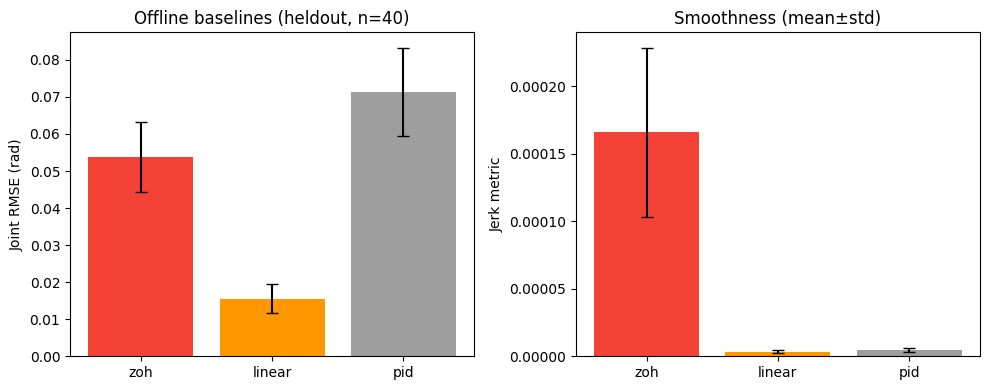

Figure saved: /home/aihimekpen/research_summer_2026/research/results/step3_baselines/baseline_comparison_heldout.png


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

sum_df = pd.DataFrame(summary)
display(sum_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(sum_df["method"], sum_df["rmse_mean"], yerr=sum_df["rmse_std"], capsize=4,
            color=["#F44336", "#FF9800", "#9E9E9E"][: len(sum_df)])
axes[0].set_ylabel("Joint RMSE (rad)")
axes[0].set_title(f"Offline baselines ({SPLIT_TAG}, n={len(EPISODES)})")
axes[1].bar(sum_df["method"], sum_df["jerk_mean"], yerr=sum_df["jerk_std"], capsize=4,
            color=["#F44336", "#FF9800", "#9E9E9E"][: len(sum_df)])
axes[1].set_ylabel("Jerk metric")
axes[1].set_title("Smoothness (mean±std)")
plt.tight_layout()
fig_path = out_dir / f"baseline_comparison_{SPLIT_TAG}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Figure saved: {fig_path}")
